In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import math
import random

import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from torch import nn, optim
from tqdm import tqdm

from efficient_kan.kan import KAN as EffKAN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Plotting the EfficientKAN activations
EfficientKAN lacks several utilities that PyKAN has. 

In this notebook we want to provide a basic implementation of the `.plot()` function for the EfficientKAN networks. This is useful for interpretation purposes.

---
## Generate the dataset
Our first data set is quite simple. The following univariate function is selected:
$$f(x)=sin(8x)$$

In [3]:
def generate_dataset(num_samples):
    x = np.random.uniform(-1, 1, num_samples)
    return np.column_stack(x), np.sin(8 * x)


train_set = generate_dataset(num_samples=20000)
test_set = generate_dataset(num_samples=5000)
datasetSinX = {
    'train_input': torch.tensor(train_set[0], dtype=torch.float32),
    'train_label': torch.tensor(train_set[1], dtype=torch.float32),
    'test_input': torch.tensor(test_set[0], dtype=torch.float32),
    'test_label': torch.tensor(test_set[1], dtype=torch.float32),
}

## EfficientKAN
The EfficientKAN network is first defined and then trained to near machine accuracy.

In [5]:
class Efficient_KAN(nn.Module):
    def __init__(self, grid_size=200, shape=None):
        super(Efficient_KAN, self).__init__()
        if shape is None:
            shape = [1, 1]
        self.layers = shape
        self.model = EffKAN(self.layers,
                            grid_size=grid_size,
                            scale_base=0,
                            sp_trainable=False,
                            sb_trainable=False,
                            ).to(device)
        self.double()

    def forward(self, x, insight=False):
        return self.model.forward_insight(x) if insight else self.model(x)

In [6]:
def train(model, optimizer, inputs: torch.Tensor, labels, epochs=5, batch_size=100):
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    for epoch in range(epochs):
        model.train()
        with tqdm(range(inputs.size(0) // batch_size)) as pbar:
            for i in pbar:
                x = inputs[i * batch_size:(i + 1) * batch_size].to(device)
                y = labels[i * batch_size:(i + 1) * batch_size].to(device)
                optimizer.zero_grad()
                output = model(x)
                output = output.squeeze()
                loss = criterion(output, y.double())
                loss.backward()
                optimizer.step(closure=lambda: loss)
                pbar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])
                scheduler.step()

In [7]:
def test(model, inputs, labels, batch_size=100):
    model.eval()
    criterion = nn.MSELoss()
    losses = []
    with torch.no_grad():
        with tqdm(range(inputs.size(0) // batch_size)) as pbar:
            for i in pbar:
                x = inputs[i * batch_size:(i + 1) * batch_size].to(device)
                y = labels[i * batch_size:(i + 1) * batch_size].to(device)
                output = model(x).cpu()
                output = output.squeeze()
                losses.append(criterion(output, y.double()))
    return (sum(losses) / len(losses)).item()

In [7]:
modelSinX = Efficient_KAN(grid_size=50, shape=[1, 1])

In [8]:
train(modelSinX, optim.Adam(modelSinX.parameters(), lr=0.025), datasetSinX["train_input"].view(-1, 1),
      datasetSinX["train_label"],
      epochs=200,
      batch_size=10000)

100%|██████████| 2/2 [00:00<00:00, 121.48it/s, loss=2.27e-6, lr=0.0168]


In [9]:
test(modelSinX, datasetSinX["test_input"].view(-1, 1), datasetSinX["test_label"])

100%|██████████| 50/50 [00:00<00:00, 2227.72it/s]


2.2137663669268637e-06

## The plot() function
The `plot()` function gives us an idea of what KAN understood the domain problem to be.

In [12]:
def plot_spline(model: EffKAN, x_range, scale=1, resolution=50):
    base_colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]

    def random_color():
        return random.random(), random.random(), random.random()

    colors = [base_colors[x] if x < len(base_colors) else random_color()
              for x in range(max(map(lambda l: l.in_features, model.layers)))]
    for layer in reversed(model.layers):
        fig, axes = plt.subplots(1, layer.in_features * layer.out_features,
                                 figsize=(2 * scale * layer.in_features * layer.out_features, 2 * scale))
        for i in range(layer.in_features):
            for j in range(layer.out_features):
                # compute on the same device and dtype as the layer parameters
                dev = layer.grid.device
                dtype = layer.grid.dtype
                x_vals = torch.linspace(x_range[0], x_range[1], resolution, device=dev, dtype=dtype)

                # B-Splines
                grid = layer.grid[j, :].unsqueeze(0)
                x = x_vals.unsqueeze(-1).unsqueeze(-1)
                bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
                for k in range(1, int(layer.spline_order) + 1):
                    denom1 = (grid[:, k:-1] - grid[:, :-(k + 1)])
                    denom2 = (grid[:, k + 1:] - grid[:, 1:(-k)])
                    denom1 = torch.where(denom1 == 0, torch.tensor(1e-9, dtype=denom1.dtype, device=denom1.device), denom1)
                    denom2 = torch.where(denom2 == 0, torch.tensor(1e-9, dtype=denom2.dtype, device=denom2.device), denom2)
                    bases = (
                                (x - grid[:, :-(k + 1)]) / denom1 * bases[:, :, :-1]
                            ) + (
                                (grid[:, k + 1:] - x) / denom2 * bases[:, :, 1:]
                            )

                weights = layer.scaled_spline_weight[j, i]
                y_vals = F.linear(bases.squeeze(), weights)
                base_w = layer.base_weight[j, i]
                # attempt to call base_activation on-tensor; coerce to device/dtype if needed
                try:
                    base_act = layer.base_activation(x_vals)
                    if isinstance(base_act, torch.Tensor):
                        base_act = base_act.to(device=dev, dtype=dtype)
                    else:
                        base_act = torch.tensor(base_act, device=dev, dtype=dtype)
                except Exception:
                    base_act = torch.tensor(layer.base_activation(x_vals.cpu().numpy()), device=dev, dtype=dtype)
                y_vals = y_vals + (base_act * base_w)

                alpha = math.tanh(abs(3 * layer.spline_scaler.view(layer.out_features, -1)[j, i].detach().cpu().item()))

                # for plotting, move to CPU and numpy
                x_np = x_vals.detach().cpu().numpy()
                y_np = y_vals.detach().cpu().numpy()

                if type(axes) is np.ndarray:
                    axes[i * layer.out_features + j].plot(x_np, y_np, alpha=alpha, color=colors[i])
                    axes[i * layer.out_features + j].grid(True)
                else:
                    axes.plot(x_np, y_np, alpha=alpha, color=colors[i])
                    axes.grid(True)

    # plt.tight_layout()
    plt.show()

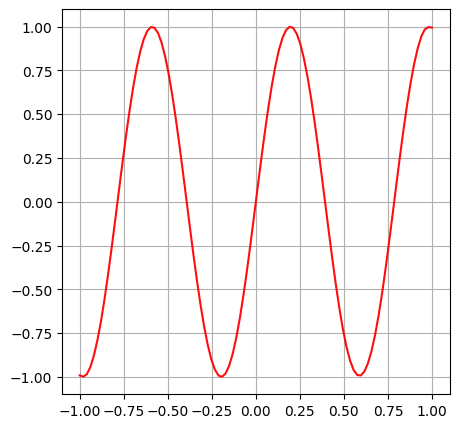

In [11]:
plot_spline(modelSinX.model, [-1, 1], scale=2.5, resolution=100)

## Verify plot correctness
The network is queried with a uniform domain distribution to prove that the previous graph was correct.

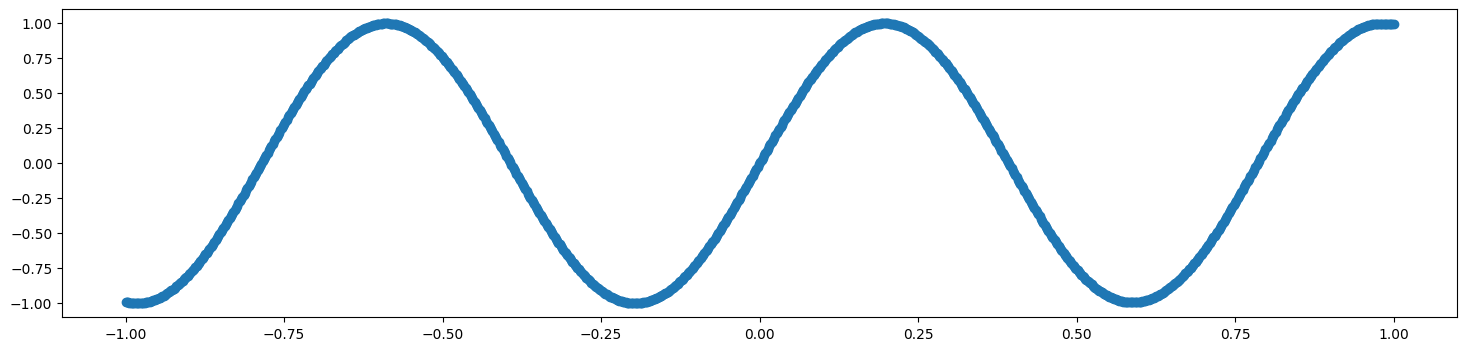

In [12]:
x_axis = torch.linspace(-1, 1, steps=1000)
y_axis = modelSinX(x_axis.view(-1, 1)).detach().numpy()
fig, ax = plt.subplots()
ax.scatter(x_axis, y_axis)
fig.set_size_inches(18, 4)
plt.show()


---
## Generate the dataset
Next, we will attempt to reproduce the multiplication experiment described in the original paper.
$$f(x,y)=x\cdot y$$

In [21]:
def generate_dataset(num_samples=1000, noise_std=1e-12):
    x, y = np.random.uniform(-1, 1, num_samples), np.random.uniform(-1, 1, num_samples)
    noise = np.random.normal(0, noise_std, num_samples)
    return np.column_stack((x, y)), x * y + noise


train_set = generate_dataset(num_samples=10000, noise_std=0)
test_set = generate_dataset(num_samples=5000, noise_std=0)
datasetXY = {
    'train_input': torch.tensor(train_set[0], dtype=torch.float32),
    'train_label': torch.tensor(train_set[1], dtype=torch.float32),
    'test_input': torch.tensor(test_set[0], dtype=torch.float32),
    'test_label': torch.tensor(test_set[1], dtype=torch.float32),
}

In [22]:
modelXY = Efficient_KAN(grid_size=5, shape=[2, 2, 1])

In [23]:
train(modelXY, optim.Adam(modelXY.parameters(), lr=0.03), datasetXY["train_input"],
      datasetXY["train_label"],
      epochs=200,
      batch_size=1000)

100%|██████████| 10/10 [00:00<00:00, 149.00it/s, loss=2.51e-5, lr=0.00406]


In [24]:
test(modelXY, datasetXY["test_input"], datasetXY["test_label"])

100%|██████████| 50/50 [00:00<00:00, 1369.60it/s]


1.8858639185845404e-05

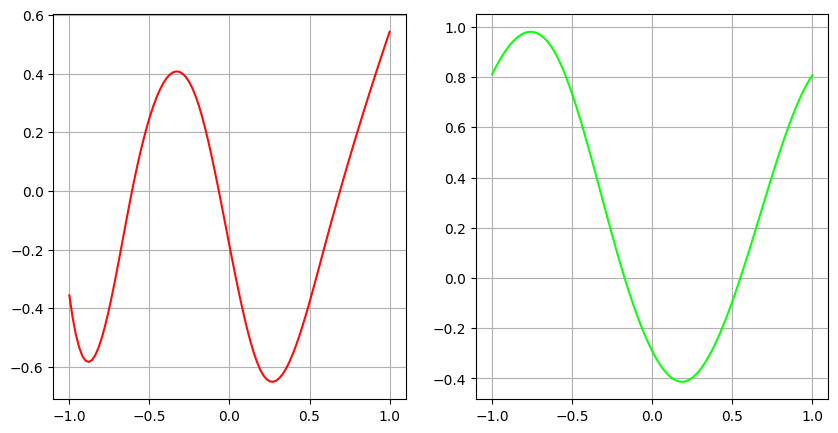

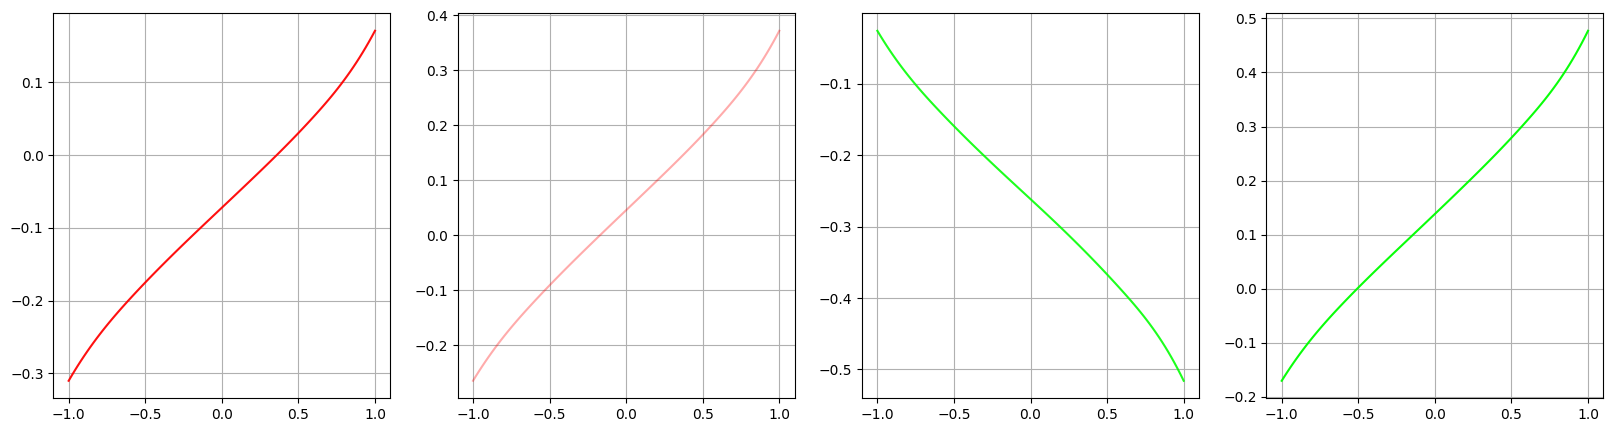

In [25]:
plot_spline(modelXY.model, [-1, 1], scale=2.5, resolution=100)

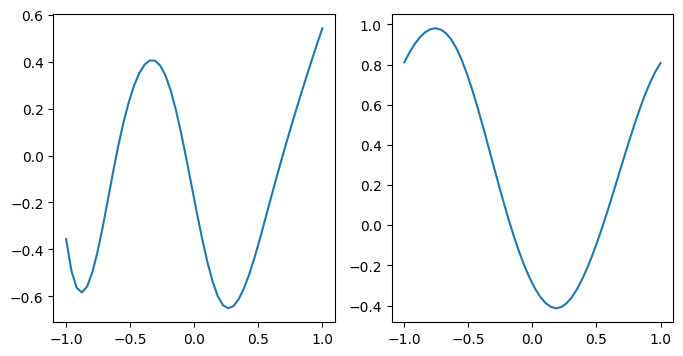

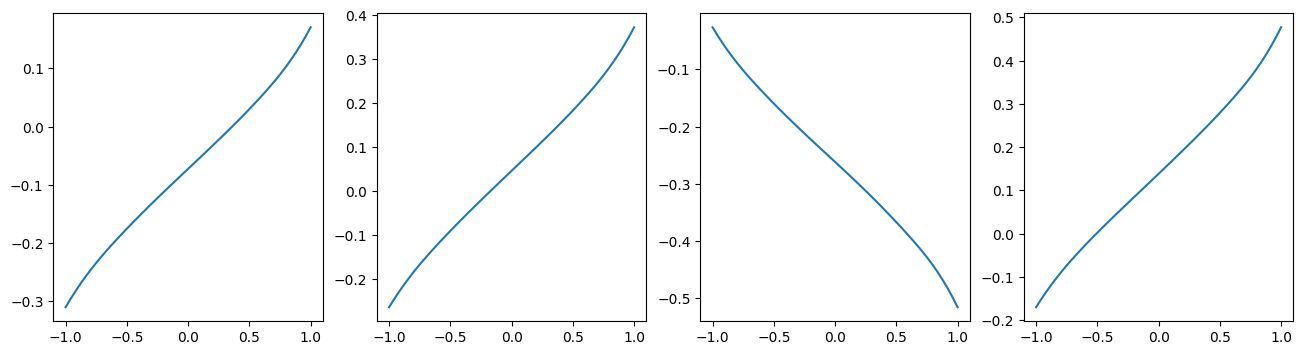

In [26]:
scale = 2
x_range = [-1, 1]
resolution = 50
for layer in reversed(modelXY.model.layers):
    fig, axes = plt.subplots(1, layer.in_features * layer.out_features,
                             figsize=(2 * scale * layer.in_features * layer.out_features, 2 * scale))

    for i in range(layer.in_features):
        for j in range(layer.out_features):
            dev = layer.grid.device
            dtype = layer.grid.dtype
            x_vals = torch.linspace(x_range[0], x_range[1], resolution, device=dev, dtype=dtype)

            # B-Splines
            grid = layer.grid[j, :].unsqueeze(0)  # The knots
            x = x_vals.unsqueeze(-1).unsqueeze(-1)
            bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(dtype)  # Determine the interval for each point
            for k_idx in range(1, int(layer.spline_order) + 1):
                denom1 = (grid[:, k_idx:-1] - grid[:, :-(k_idx + 1)])
                denom2 = (grid[:, k_idx + 1:] - grid[:, 1:(-k_idx)])
                denom1 = torch.where(denom1 == 0, torch.tensor(1e-9, dtype=dtype, device=dev), denom1)
                denom2 = torch.where(denom2 == 0, torch.tensor(1e-9, dtype=dtype, device=dev), denom2)
                
                bases = (
                                (x - grid[:, : -(k_idx + 1)])
                                / denom1
                                * bases[:, :, :-1]
                        ) + (
                                (grid[:, k_idx + 1:] - x)
                                / denom2
                                * bases[:, :, 1:]
                        )

            y_vals = F.linear(bases.squeeze(), layer.scaled_spline_weight[j, i]).detach()
            
            try:
                base_act = layer.base_activation(x_vals)
            except Exception:
                base_act = torch.tensor(layer.base_activation(x_vals.cpu().numpy()), device=dev, dtype=dtype)
                
            y_vals += (base_act * layer.base_weight[j, i]).detach()

            x_np = x_vals.cpu().numpy()
            y_np = y_vals.cpu().numpy()

            if type(axes) is np.ndarray:
                axes[i * layer.out_features + j].plot(x_np, y_np)
            else:
                axes.plot(x_np, y_np)

# plt.tight_layout()
plt.show()

## Last try
Next, we check that the plotting function also works with wider layers
$$f(x,y)=sin(8x)+cos(4y)$$

In [19]:
def generate_dataset(num_samples=1000, noise_std=1e-12):
    x, y = np.random.uniform(-1, 1, num_samples), np.random.uniform(-1, 1, num_samples)
    return np.column_stack((x, y)), np.sin(8 * x) + np.cos(4 * y)


train_set = generate_dataset(num_samples=10000, noise_std=0)
test_set = generate_dataset(num_samples=5000, noise_std=0)
datasetSinXCosY = {
    'train_input': torch.tensor(train_set[0], dtype=torch.float32),
    'train_label': torch.tensor(train_set[1], dtype=torch.float32),
    'test_input': torch.tensor(test_set[0], dtype=torch.float32),
    'test_label': torch.tensor(test_set[1], dtype=torch.float32),
}

In [20]:
modelSinXCosY = Efficient_KAN(grid_size=10, shape=[2, 1])

In [21]:
train(modelSinXCosY, optim.Adam(modelSinXCosY.parameters(), lr=0.025), datasetSinXCosY["train_input"],
      datasetSinXCosY["train_label"],
      epochs=200,
      batch_size=1000)

100%|██████████| 10/10 [00:00<00:00, 262.63it/s, loss=0.000516, lr=0.00338]


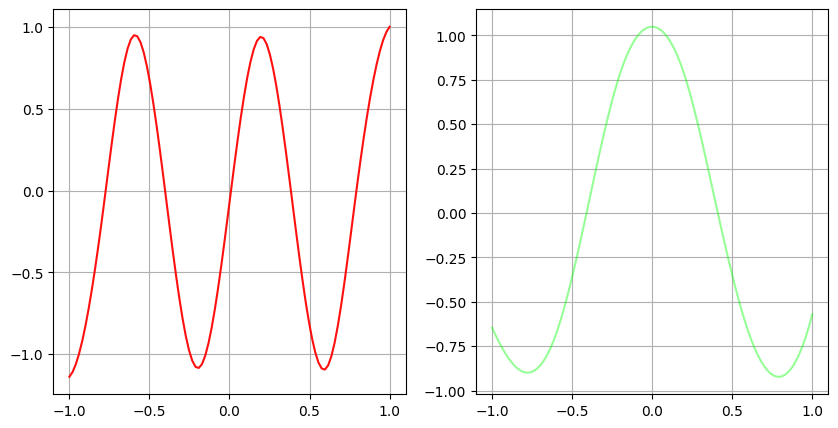

In [22]:
plot_spline(modelSinXCosY.model, [-1, 1], scale=2.5, resolution=100)